In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
import xgboost as xgb
import warnings

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')

print('Imports OK')

Imports OK


In [2]:
# Load combined participants data
path = r"/home/karthik/Desktop/llm_eval/combined_participants.csv"
df = pd.read_csv(path)

# Convert drowsiness_level from strings to numeric
drowsiness_map = {'Low': 1, 'Moderate': 2, 'High': 3}
df['drowsiness_level'] = df['drowsiness_level'].map(drowsiness_map)

# Remove rows with NaN drowsiness level
df = df.dropna(subset=['drowsiness_level'])

print(f"Data shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"\nDrowsiness levels: {sorted(df['drowsiness_level'].unique())}")
print(f"\nParticipants: {sorted(df['participant'].unique())}")

Data shape: (430, 16)
Columns: ['participant', 'initial_timestamp', 'window_id', 'video', 'drowsiness_level', 'metric_PERCLOS', 'metric_BlinkRate', 'blink_duration_mean', 'blink_duration_std', 'blink_duration_max', 'metric_YawnRate', 'metric_Entropy', 'metric_SteeringRate', 'metric_SDLP', 'HRV_RMSSD', 'HRV_SD1']

Drowsiness levels: [np.float64(1.0), np.float64(2.0), np.float64(3.0)]

Participants: ['A', 'D', 'GK', 'MK', 'MV', 'SB', 'TG', 'V']


In [3]:
# ── FEATURE DEFINITIONS ────────────────────────────────────────────────────

# Visual + Behavioral + Driving features (NO HRV)
FEATURES_WITHOUT_HRV = [
    'metric_PERCLOS',           # % eyes closed
    'metric_BlinkRate',         # blinks per minute
    'blink_duration_mean',      # avg blink duration
    'blink_duration_max',       # max blink duration
    'metric_YawnRate',          # yawns per minute
    'metric_Entropy',           # steering entropy
    'metric_SteeringRate',      # steering reversals per sec
    'metric_SDLP',              # std dev of lane position
]

# HRV features only
HRV_FEATURES = [
    'HRV_RMSSD',                # Root Mean Square of Successive Differences
    'HRV_SD1',                  # Poincaré plot SD1
]

# ALL features: visual + behavioral + driving + HRV
FEATURES_WITH_HRV = FEATURES_WITHOUT_HRV + HRV_FEATURES

print(f"Features WITHOUT HRV: {len(FEATURES_WITHOUT_HRV)} features")
print(f"HRV Features: {len(HRV_FEATURES)} features")
print(f"Features WITH HRV: {len(FEATURES_WITH_HRV)} features")

Features WITHOUT HRV: 8 features
HRV Features: 2 features
Features WITH HRV: 10 features


In [4]:
# ── PREPROCESSING FUNCTION ─────────────────────────────────────────────────

def train_xgboost_cv(X, y, feature_names, n_splits=5, random_state=42):
    """
    Train XGBoost with stratified K-fold CV and return results.
    
    Args:
        X: feature matrix (n_samples, n_features)
        y: labels (1, 2, 3) for drowsiness levels
        feature_names: list of feature names
        n_splits: number of CV folds
        random_state: random seed
    
    Returns:
        dict with results
    """
    
    # Remove samples with any missing values
    valid_idx = ~np.isnan(X).any(axis=1)
    X_clean = X[valid_idx]
    y_clean = y[valid_idx]
    
    if len(X_clean) == 0:
        return None
    
    # StandardScaler
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_clean)
    
    # PCA (90% variance)
    pca_explorer = PCA(random_state=random_state)
    pca_explorer.fit(X_scaled)
    cumsum_var = np.cumsum(pca_explorer.explained_variance_ratio_)
    n_comp = max(2, int(np.searchsorted(cumsum_var, 0.90)) + 1)
    
    pca = PCA(n_components=n_comp, random_state=random_state)
    X_pca = pca.fit_transform(X_scaled)
    
    # Convert to 0-indexed for sklearn (1,2,3 -> 0,1,2)
    y_clean_numeric = np.asarray(y_clean, dtype=int)
    y_clean_0idx = y_clean_numeric - 1
    
    # Adaptive folds (can't exceed smallest class count)
    k = min(n_splits, int(pd.Series(y_clean_0idx).value_counts().min()))
    cv = StratifiedKFold(n_splits=k, shuffle=True, random_state=random_state)
    
    # XGBoost
    clf = xgb.XGBClassifier(
        n_estimators=150,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='mlogloss',
        random_state=random_state,
        verbosity=0,
    )
    
    # Cross-validation
    cv_scores = cross_val_score(clf, X_pca, y_clean_0idx, cv=cv, scoring='accuracy')
    
    # Get predictions from CV
    y_pred = np.zeros_like(y_clean_0idx)
    for train_idx, test_idx in cv.split(X_pca, y_clean_0idx):
        clf.fit(X_pca[train_idx], y_clean_0idx[train_idx])
        y_pred[test_idx] = clf.predict(X_pca[test_idx])
    
    y_pred_labels = y_pred + 1  # Convert back to 1, 2, 3
    
    f1_macro = f1_score(y_clean_numeric, y_pred_labels, average='macro', zero_division=0)
    f1_weighted = f1_score(y_clean_numeric, y_pred_labels, average='weighted', zero_division=0)
    
    return {
        'X_clean': X_clean,
        'y_true': y_clean_numeric,
        'y_pred': y_pred_labels,
        'cv_scores': cv_scores,
        'accuracy': cv_scores.mean(),
        'accuracy_std': cv_scores.std(),
        'f1_macro': f1_macro,
        'f1_weighted': f1_weighted,
        'n_samples': len(X_clean),
        'n_components': n_comp,
        'n_folds': k,
        'explained_var': pca.explained_variance_ratio_.sum(),
    }

print("Train function defined OK")

Train function defined OK


In [5]:
# ── AGGREGATE RESULTS (ALL PARTICIPANTS) ───────────────────────────────────

results_comparison = {}  # feature_set → dict with results

for feature_set_name, features in [
    ('WITHOUT HRV', FEATURES_WITHOUT_HRV),
    ('WITH HRV', FEATURES_WITH_HRV),
]:
    print(f"\n{'='*60}")
    print(f"Training XGBoost {feature_set_name}")
    print(f"Features: {len(features)} feature(s)")
    print(f"{'='*60}")
    
    # Extract feature matrix and labels across all participants
    X = df[features].values
    y = df['drowsiness_level'].values
    
    result = train_xgboost_cv(X, y, features)
    
    if result:
        results_comparison[feature_set_name] = result
        print(f"\n✓ Trained on {result['n_samples']} samples")
        print(f"  CV Accuracy: {result['accuracy']:.4f} ± {result['accuracy_std']:.4f}")
        print(f"  F1-Macro:    {result['f1_macro']:.4f}")
        print(f"  F1-Weighted: {result['f1_weighted']:.4f}")
        print(f"  PCA Components: {result['n_components']} (explains {result['explained_var']:.1%})")
        print(f"  CV Folds: {result['n_folds']}")


Training XGBoost WITHOUT HRV
Features: 8 feature(s)

✓ Trained on 430 samples
  CV Accuracy: 0.6023 ± 0.0392
  F1-Macro:    0.5596
  F1-Weighted: 0.5964
  PCA Components: 5 (explains 97.6%)
  CV Folds: 5

Training XGBoost WITH HRV
Features: 10 feature(s)

✓ Trained on 425 samples
  CV Accuracy: 0.6165 ± 0.0491
  F1-Macro:    0.5660
  F1-Weighted: 0.6123
  PCA Components: 5 (explains 90.1%)
  CV Folds: 5


In [6]:
# ── PER-PARTICIPANT COMPARISON ─────────────────────────────────────────────

print(f"\n{'='*80}")
print("Per-Participant Results: WITH HRV vs WITHOUT HRV")
print(f"{'='*80}\n")

per_participant = {}

for participant in sorted(df['participant'].unique()):
    df_p = df[df['participant'] == participant].copy()
    
    results_per = {}
    
    for feature_set_name, features in [
        ('without_hrv', FEATURES_WITHOUT_HRV),
        ('with_hrv', FEATURES_WITH_HRV),
    ]:
        X = df_p[features].values
        y = df_p['drowsiness_level'].values
        
        result = train_xgboost_cv(X, y, features, n_splits=5)
        results_per[feature_set_name] = result
    
    per_participant[participant] = results_per
    
    # Print comparison
    r_without = results_per['without_hrv']
    r_with = results_per['with_hrv']
    
    if r_without and r_with:
        acc_diff = r_with['accuracy'] - r_without['accuracy']
        f1_diff = r_with['f1_macro'] - r_without['f1_macro']
        
        print(f"{participant:12} | Without HRV: {r_without['accuracy']:.3f}±{r_without['accuracy_std']:.3f}  "
              f"With HRV: {r_with['accuracy']:.3f}±{r_with['accuracy_std']:.3f}  "
              f"Δ Accuracy: {acc_diff:+.3f}")
        print(f"{'':12} | F1-Macro (without): {r_without['f1_macro']:.3f}  "
              f"(with): {r_with['f1_macro']:.3f}  Δ: {f1_diff:+.3f}")
        print()


Per-Participant Results: WITH HRV vs WITHOUT HRV

A            | Without HRV: 0.533±0.000  With HRV: 0.583±0.017  Δ Accuracy: +0.050
             | F1-Macro (without): 0.360  (with): 0.394  Δ: +0.033

D            | Without HRV: 0.950±0.000  With HRV: 0.950±0.000  Δ Accuracy: +0.000
             | F1-Macro (without): 0.487  (with): 0.487  Δ: +0.000

GK           | Without HRV: 1.000±0.000  With HRV: 1.000±0.000  Δ Accuracy: +0.000
             | F1-Macro (without): 1.000  (with): 1.000  Δ: +0.000

MK           | Without HRV: 0.327±0.122  With HRV: 0.329±0.105  Δ Accuracy: +0.002
             | F1-Macro (without): 0.300  (with): 0.285  Δ: -0.015

MV           | Without HRV: 0.798±0.104  With HRV: 0.798±0.104  Δ Accuracy: +0.000
             | F1-Macro (without): 0.755  (with): 0.723  Δ: -0.032

SB           | Without HRV: 0.552±0.171  With HRV: 0.529±0.111  Δ Accuracy: -0.024
             | F1-Macro (without): 0.492  (with): 0.512  Δ: +0.021

TG           | Without HRV: 0.714±0.143  Wi

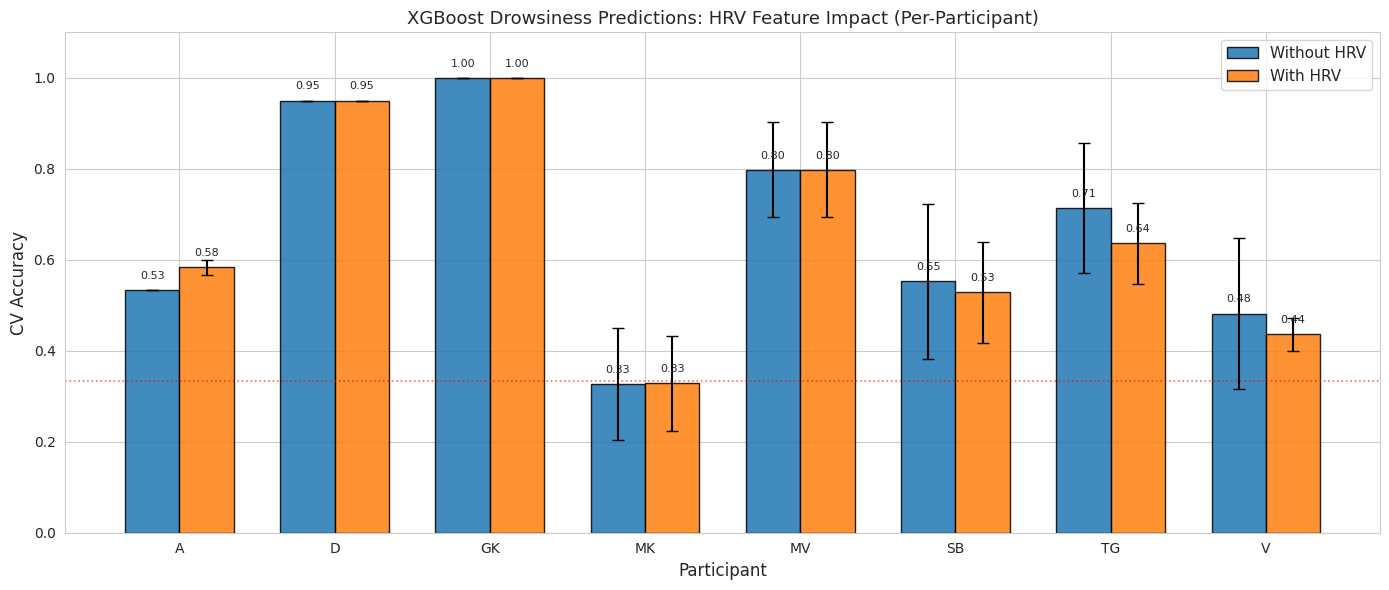

In [7]:
# ── VISUALIZATION: ACCURACY COMPARISON ──────────────────────────────────────

participants = sorted(per_participant.keys())
acc_without = []
acc_with = []
acc_without_std = []
acc_with_std = []

for p in participants:
    r_without = per_participant[p]['without_hrv']
    r_with = per_participant[p]['with_hrv']
    
    if r_without:
        acc_without.append(r_without['accuracy'])
        acc_without_std.append(r_without['accuracy_std'])
    if r_with:
        acc_with.append(r_with['accuracy'])
        acc_with_std.append(r_with['accuracy_std'])

x = np.arange(len(participants))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 6))
bars1 = ax.bar(x - width/2, acc_without, width, label='Without HRV', 
               yerr=acc_without_std, capsize=4, alpha=0.85, edgecolor='black')
bars2 = ax.bar(x + width/2, acc_with, width, label='With HRV', 
               yerr=acc_with_std, capsize=4, alpha=0.85, edgecolor='black')

ax.set_xlabel('Participant', fontsize=12)
ax.set_ylabel('CV Accuracy', fontsize=12)
ax.set_title('XGBoost Drowsiness Predictions: HRV Feature Impact (Per-Participant)', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(participants)
ax.legend(fontsize=11)
ax.set_ylim(0, 1.1)
ax.axhline(0.333, color='red', linestyle=':', linewidth=1.2, alpha=0.6)

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                f'{height:.2f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

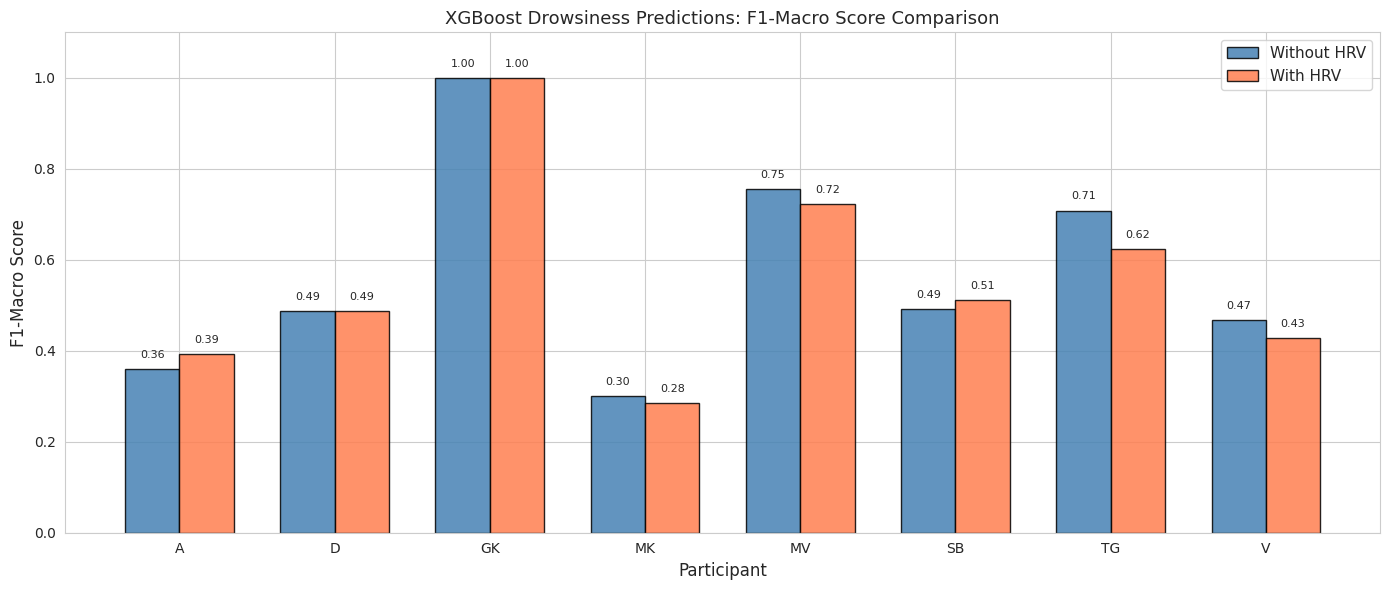

In [8]:
# ── F1-MACRO COMPARISON ─────────────────────────────────────────────────────

f1_without = []
f1_with = []

for p in participants:
    r_without = per_participant[p]['without_hrv']
    r_with = per_participant[p]['with_hrv']
    
    if r_without:
        f1_without.append(r_without['f1_macro'])
    if r_with:
        f1_with.append(r_with['f1_macro'])

x = np.arange(len(participants))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 6))
bars1 = ax.bar(x - width/2, f1_without, width, label='Without HRV', 
               alpha=0.85, edgecolor='black', color='steelblue')
bars2 = ax.bar(x + width/2, f1_with, width, label='With HRV', 
               alpha=0.85, edgecolor='black', color='coral')

ax.set_xlabel('Participant', fontsize=12)
ax.set_ylabel('F1-Macro Score', fontsize=12)
ax.set_title('XGBoost Drowsiness Predictions: F1-Macro Score Comparison', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(participants)
ax.legend(fontsize=11)
ax.set_ylim(0, 1.1)

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                f'{height:.2f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

In [9]:
# ── IMPROVEMENT SUMMARY ─────────────────────────────────────────────────────

print(f"\n{'='*80}")
print("IMPACT OF HRV FEATURES ON MODEL PERFORMANCE")
print(f"{'='*80}\n")

improvements = []

for p in participants:
    r_without = per_participant[p]['without_hrv']
    r_with = per_participant[p]['with_hrv']
    
    if r_without and r_with:
        acc_improvement = r_with['accuracy'] - r_without['accuracy']
        f1_improvement = r_with['f1_macro'] - r_without['f1_macro']
        
        improvements.append({
            'participant': p,
            'acc_improvement': acc_improvement,
            'f1_improvement': f1_improvement,
            'acc_without': r_without['accuracy'],
            'acc_with': r_with['accuracy'],
        })

# Summary statistics
acc_improvements = [x['acc_improvement'] for x in improvements]
f1_improvements = [x['f1_improvement'] for x in improvements]

print(f"Average Accuracy Improvement: {np.mean(acc_improvements):+.4f}")
print(f"  - Std Dev: {np.std(acc_improvements):.4f}")
print(f"  - Min: {np.min(acc_improvements):+.4f}")
print(f"  - Max: {np.max(acc_improvements):+.4f}")

print(f"\nAverage F1-Macro Improvement: {np.mean(f1_improvements):+.4f}")
print(f"  - Std Dev: {np.std(f1_improvements):.4f}")
print(f"  - Min: {np.min(f1_improvements):+.4f}")
print(f"  - Max: {np.max(f1_improvements):+.4f}")

# Count improvements
n_improved = sum(1 for x in improvements if x['acc_improvement'] > 0)
n_degraded = sum(1 for x in improvements if x['acc_improvement'] < 0)
n_same = sum(1 for x in improvements if x['acc_improvement'] == 0)

print(f"\nParticipants with IMPROVED accuracy: {n_improved}/{len(improvements)}")
print(f"Participants with DEGRADED accuracy: {n_degraded}/{len(improvements)}")
print(f"Participants with NO CHANGE: {n_same}/{len(improvements)}")

print(f"\nDetailed breakdown (sorted by improvement):")
for imp in sorted(improvements, key=lambda x: x['acc_improvement'], reverse=True):
    print(f"  {imp['participant']:6} | Acc: {imp['acc_without']:.3f} → {imp['acc_with']:.3f} "
          f"({imp['acc_improvement']:+.3f}) | F1Δ: {imp['f1_improvement']:+.3f}")


IMPACT OF HRV FEATURES ON MODEL PERFORMANCE

Average Accuracy Improvement: -0.0119
  - Std Dev: 0.0355
  - Min: -0.0780
  - Max: +0.0500

Average F1-Macro Improvement: -0.0147
  - Std Dev: 0.0349
  - Min: -0.0844
  - Max: +0.0333

Participants with IMPROVED accuracy: 2/8
Participants with DEGRADED accuracy: 3/8
Participants with NO CHANGE: 3/8

Detailed breakdown (sorted by improvement):
  A      | Acc: 0.533 → 0.583 (+0.050) | F1Δ: +0.033
  MK     | Acc: 0.327 → 0.329 (+0.002) | F1Δ: -0.015
  D      | Acc: 0.950 → 0.950 (+0.000) | F1Δ: +0.000
  GK     | Acc: 1.000 → 1.000 (+0.000) | F1Δ: +0.000
  MV     | Acc: 0.798 → 0.798 (+0.000) | F1Δ: -0.032
  SB     | Acc: 0.552 → 0.529 (-0.024) | F1Δ: +0.021
  V      | Acc: 0.482 → 0.436 (-0.045) | F1Δ: -0.040
  TG     | Acc: 0.714 → 0.636 (-0.078) | F1Δ: -0.084


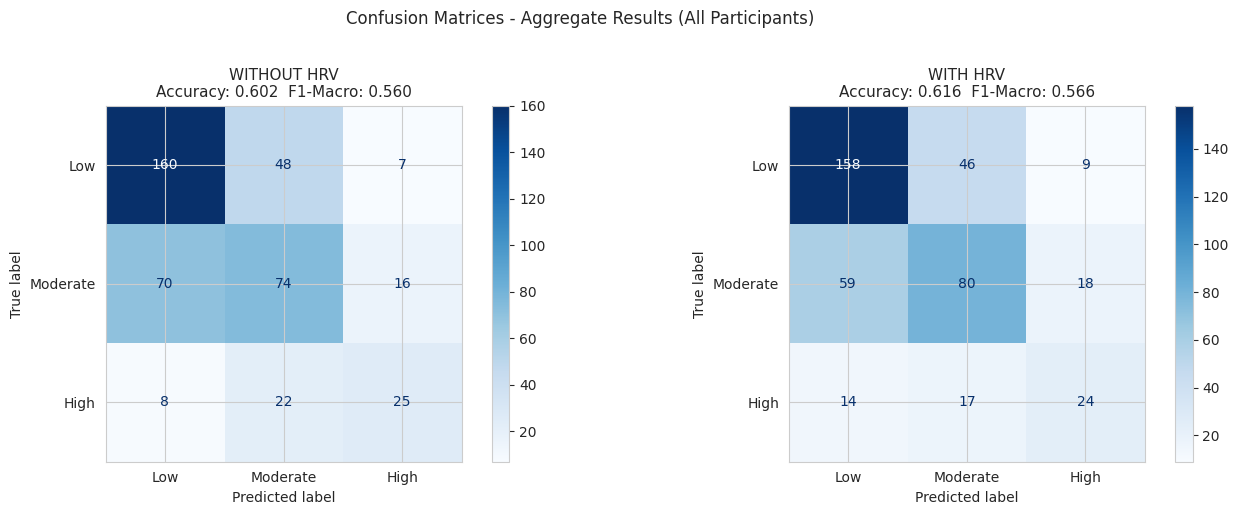

In [10]:
# ── CONFUSION MATRICES COMPARISON (AGGREGATE) ──────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, (feature_set_name, features) in enumerate([
    ('WITHOUT HRV', FEATURES_WITHOUT_HRV),
    ('WITH HRV', FEATURES_WITH_HRV),
]):
    
    result = results_comparison[feature_set_name]
    cm = confusion_matrix(result['y_true'], result['y_pred'], labels=[1, 2, 3])
    
    ConfusionMatrixDisplay(cm, display_labels=['Low', 'Moderate', 'High']).plot(
        ax=axes[idx], colorbar=True, cmap='Blues'
    )
    axes[idx].set_title(f'{feature_set_name}\nAccuracy: {result["accuracy"]:.3f}  '
                        f'F1-Macro: {result["f1_macro"]:.3f}', fontsize=11)

plt.suptitle('Confusion Matrices - Aggregate Results (All Participants)', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

In [11]:
# ── CLASSIFICATION REPORTS ────────────────────────────────────────────────

LABEL_NAMES = {1: 'Low', 2: 'Moderate', 3: 'High'}

for feature_set_name in ['WITHOUT HRV', 'WITH HRV']:
    result = results_comparison[feature_set_name]
    print(f"\n{'='*60}")
    print(f"Classification Report: {feature_set_name}")
    print(f"{'='*60}")
    
    present_labels = sorted(set(result['y_true']) | set(result['y_pred']))
    target_names = [LABEL_NAMES[l] for l in present_labels]
    
    print(classification_report(result['y_true'], result['y_pred'],
                                labels=present_labels,
                                target_names=target_names,
                                zero_division=0))


Classification Report: WITHOUT HRV
              precision    recall  f1-score   support

         Low       0.67      0.74      0.71       215
    Moderate       0.51      0.46      0.49       160
        High       0.52      0.45      0.49        55

    accuracy                           0.60       430
   macro avg       0.57      0.55      0.56       430
weighted avg       0.59      0.60      0.60       430


Classification Report: WITH HRV
              precision    recall  f1-score   support

         Low       0.68      0.74      0.71       213
    Moderate       0.56      0.51      0.53       157
        High       0.47      0.44      0.45        55

    accuracy                           0.62       425
   macro avg       0.57      0.56      0.57       425
weighted avg       0.61      0.62      0.61       425

